In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.constants import h, k
import os
import random

import scienceplots as splt
matplotlib.pyplot.style.use(['science', 'notebook', 'ieee'])
matplotlib.pyplot.rcParams['font.family'] = 'Times New Roman'



# Aggiunge src alla path dei moduli
project_root = Path.cwd().parent.parent  # da molecular_QLS -> notebooks -> project_root
sys.path.append(str(project_root / "src"))

# Ora puoi importare
import utils as ut
# import qls as qls
from saving import save_figure_in_images
from molecules.molecule import CaH, CaOH, CaOH_dm2, CaH_dm2, Molecule
import QLS.spectrum as spectrum
import QLS.pumping as pumping
import QLS.state_dist as state_dist


In [2]:
# Taken from Chou et al.

gj_list: list[float] = [-1.35, -1.35, -1.35, -1.34, -1.34, -1.34, -1.34, -1.34, -1.33, -1.33, -1.33, -1.32, -1.32, -1.31, -1.31]

cij_list: list[float] = [8.27, 8.26, 8.26, 8.26, 8.26, 8.25, 8.25, 8.24, 8.24, 8.23, 8.22, 8.21, 8.20, 8.19, 8.18]

## Quantum Logic Spectroscopy

In this part we compute the unpumped and the pumped spectrum for CaH without the ODF and without experimental imperfections. In addition, the unpumped spectrum is obsolete since the corrected pumped spectrum should consider the state distribution yielded by the correct pumping scheme.

In [3]:
b_field_gauss = 3.6
j_max = 14

# I compute the molecule 
cah1 = CaH.create_molecule_data(b_field_gauss=b_field_gauss, j_max=j_max, gj_list = gj_list, cij_list = cij_list)

temperature = 300
states = state_dist.States(cah1, temperature)


# Then I apply the external Raman pulse. 
spectrum_list = {
    "duration_us": 1000.0,
    "rabi_rate_mhz": 2*np.pi*0.005,
    "max_frequency_mhz": 0.05,        # 50 kHz
    "scan_points": 1000,
    "dephased" : False,
    "coherence_time_us": 100,
    "is_minus" : True
}


# Then I pump the system n times to improve the population
pump_sequences = {
    "frequency_mhz": -0.006,
    "num_pumps": 200,
    "duration_us": 1000.0,
    "rabi_rate_mhz": 2*np.pi*0.004,
    "dephased": True,
    "coherence_time_us": 100,
    "is_minus": True,    
}


# pump_sequences = [
#     {
#         "frequency_mhz": -0.006,
#         "num_pumps": 200,
#         "duration_us": 1000.0,
#         "rabi_rate_mhz": 2*np.pi*0.004,
#         "dephased": False,
#         "coherence_time_us": 100,
#         "is_minus": True,
#     },
#     {
#         "frequency_mhz": -0.006,
#         "num_pumps": 200,
#         "duration_us": 1000.0,
#         "rabi_rate_mhz": 2*np.pi*0.004,
#         "dephased": True,
#         "coherence_time_us": 100,
#         "is_minus": True,
#     }
# ]



# laser_miscalibration = {
#     "frequency": {"type": "abs_gaussian", "level": 0.00005},
#     "rabi_rate": {"type": "rel_gaussian", "level": 0.1}
# }

# # If I want both lasers to have the SAME MISCALIBRATION
# seed_miscalibration = random.randint(0, 10000)

# # SHOT TO SHOT FLUCTUATIONS
# noise_params = {
#     "frequency": {"type": "abs_gaussian", "level": 0.00003},
#     "rabi_rate": {"type": "rel_gaussian", "level": 0.01}
# }

# false_positive_rate = 0.015

Saved molecule data in:
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[14]_states.csv
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[14]_transitions.csv


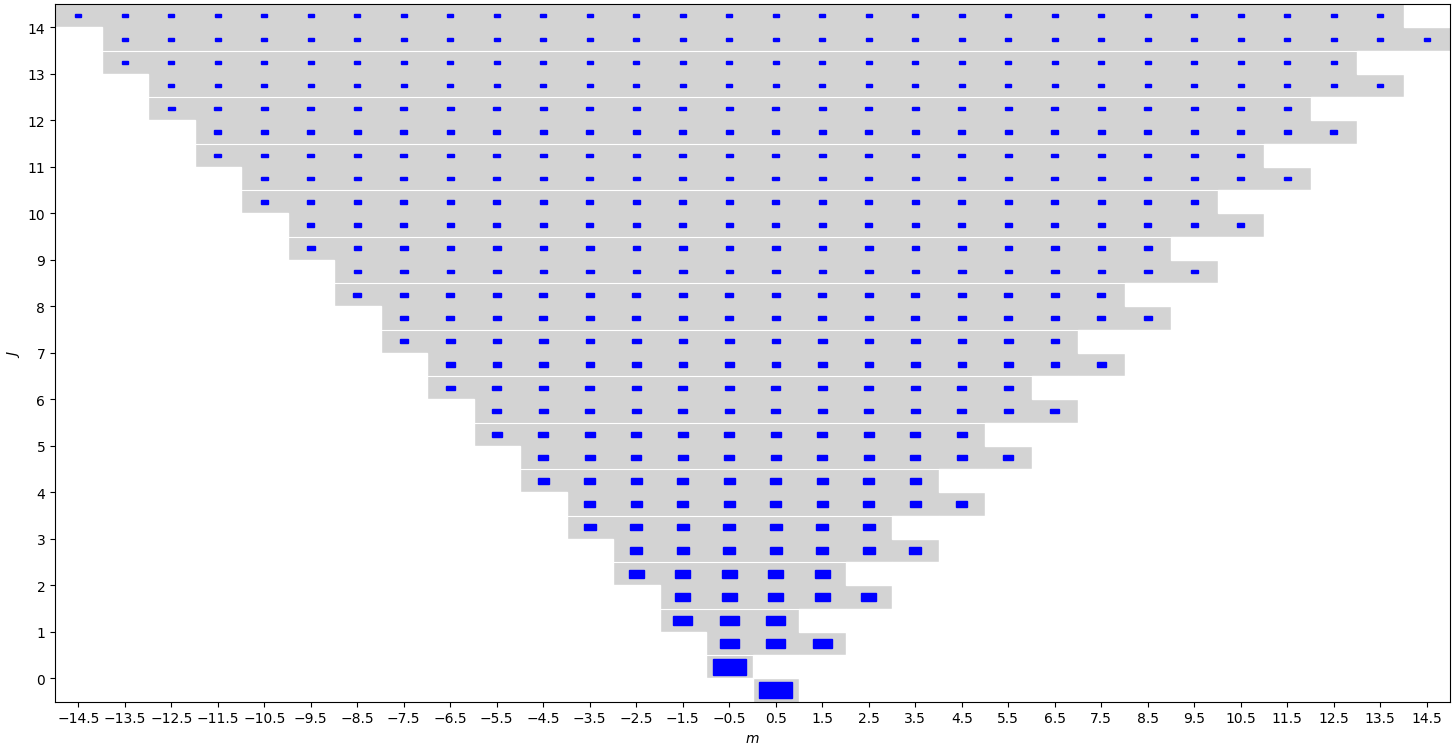

In [4]:
matrix = ut.heatmap_state_pop(cah1.state_df, j_max, normalize = True)

Saved figure in: /home/stripzio/bayesian-qls/re_project/images/unpumped.svg


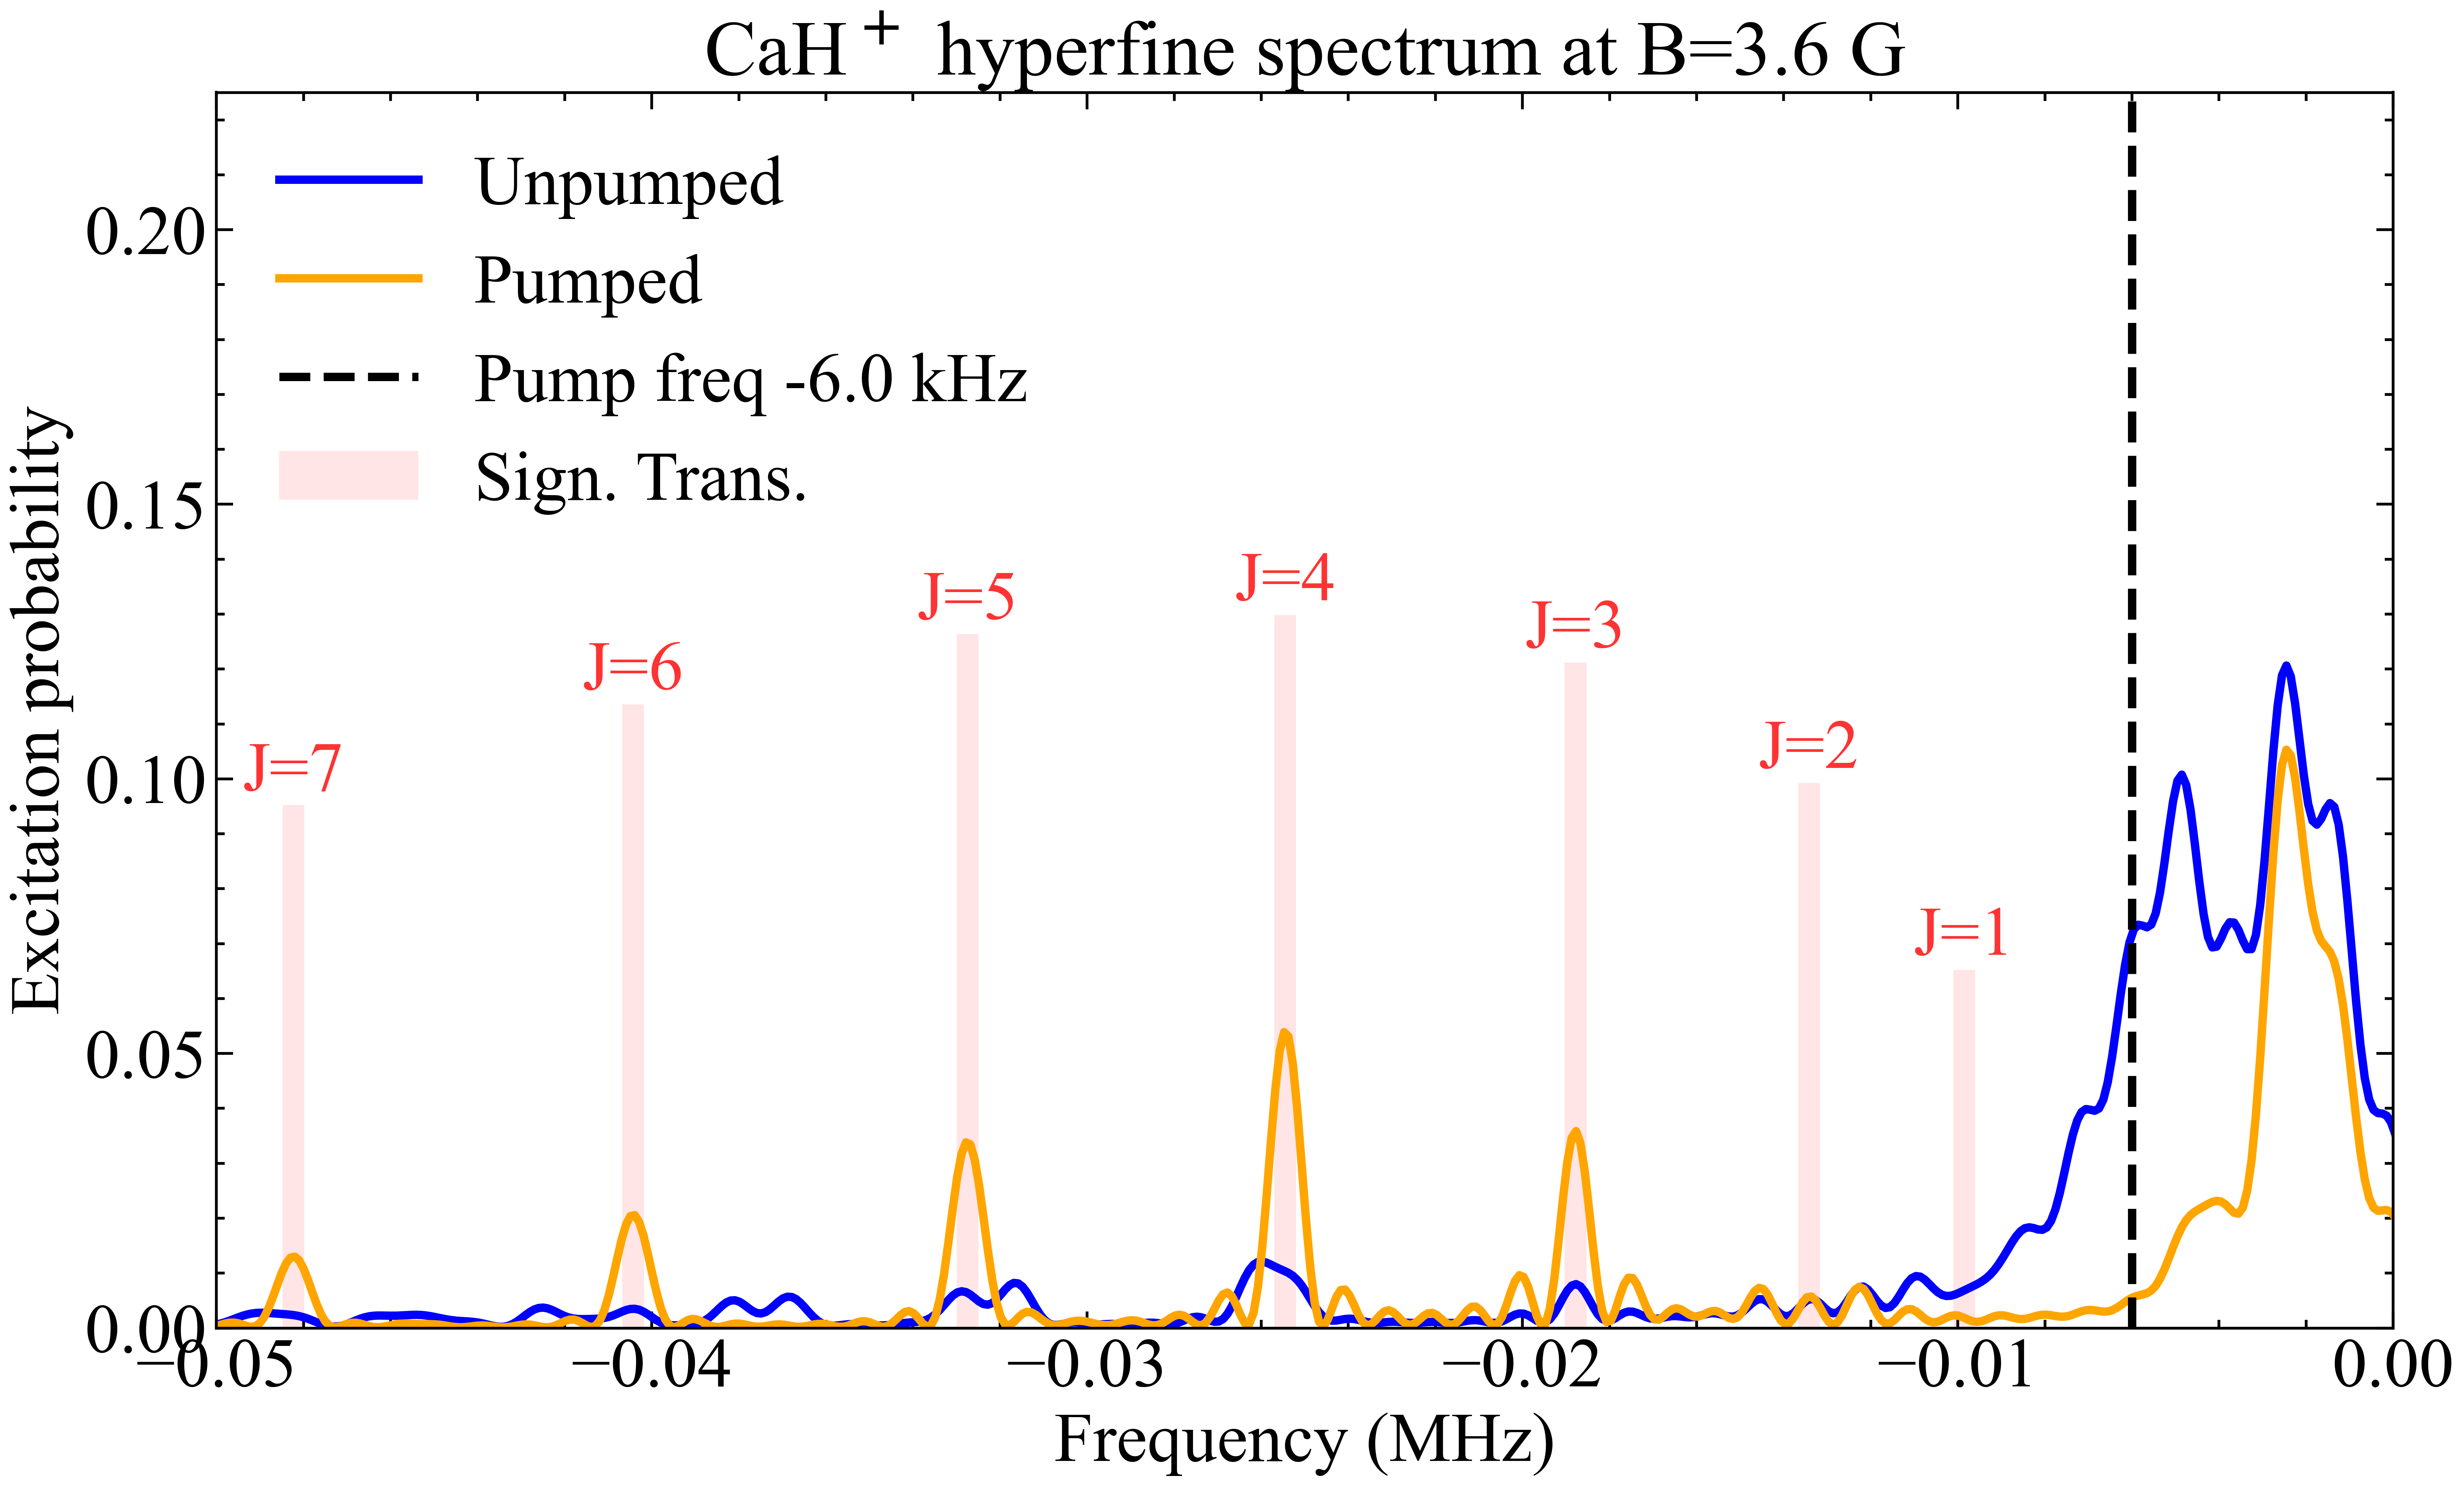

In [5]:
spectrum.unpumped_pumped(b_field_gauss, j_max, cah1, states, spectrum_list, pump_sequences, 
                filename = "unpumped.svg")

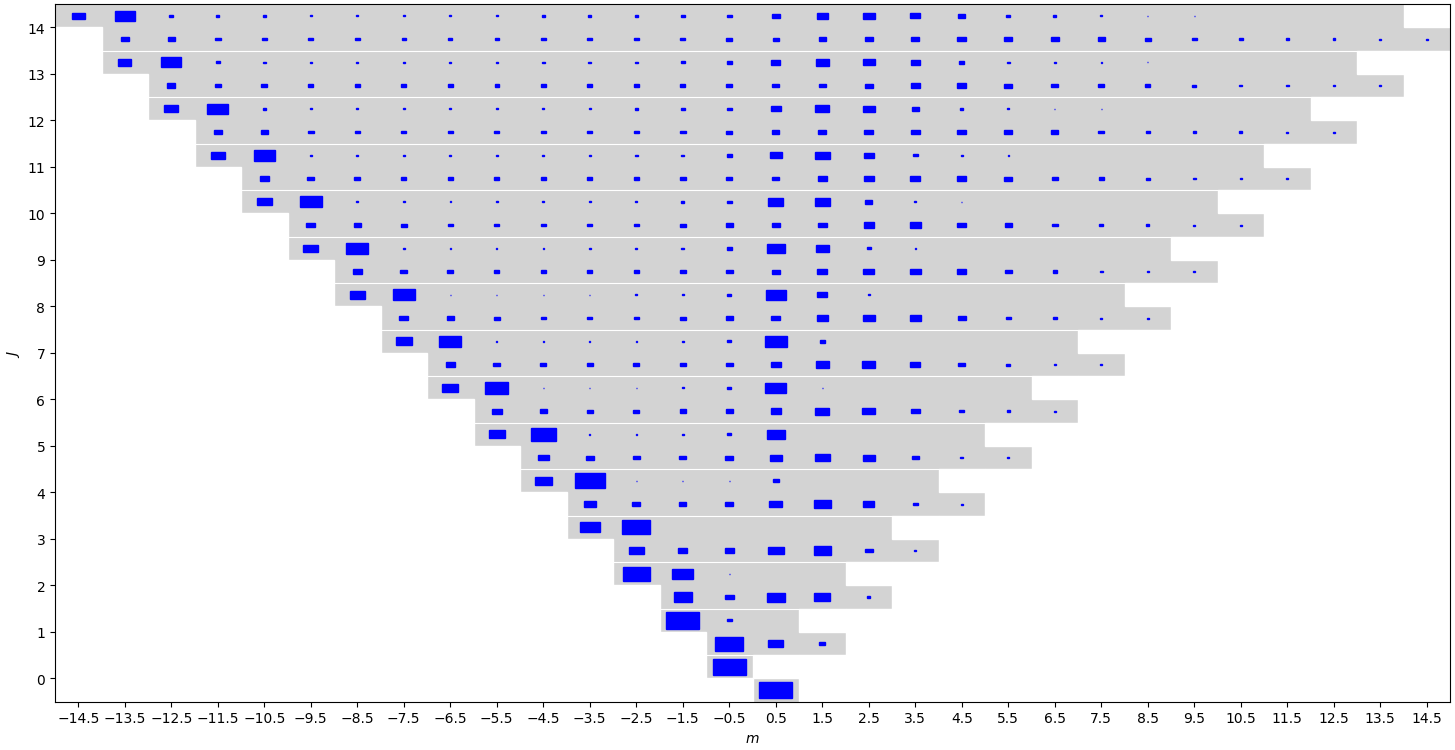

In [6]:
cah1.state_df["state_dist"] = states.dist
matrix = ut.heatmap_state_pop(cah1.state_df, j_max, normalize = True)

The data for the simulation are listed in the cell below. <br> 
Here, we perform twp pumping procedures at frequency -6 kHz and -2 kHz

Saved molecule data in:
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[14]_states.csv
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[14]_transitions.csv
Saved figure in: /home/stripzio/bayesian-qls/re_project/images/unpumped.svg


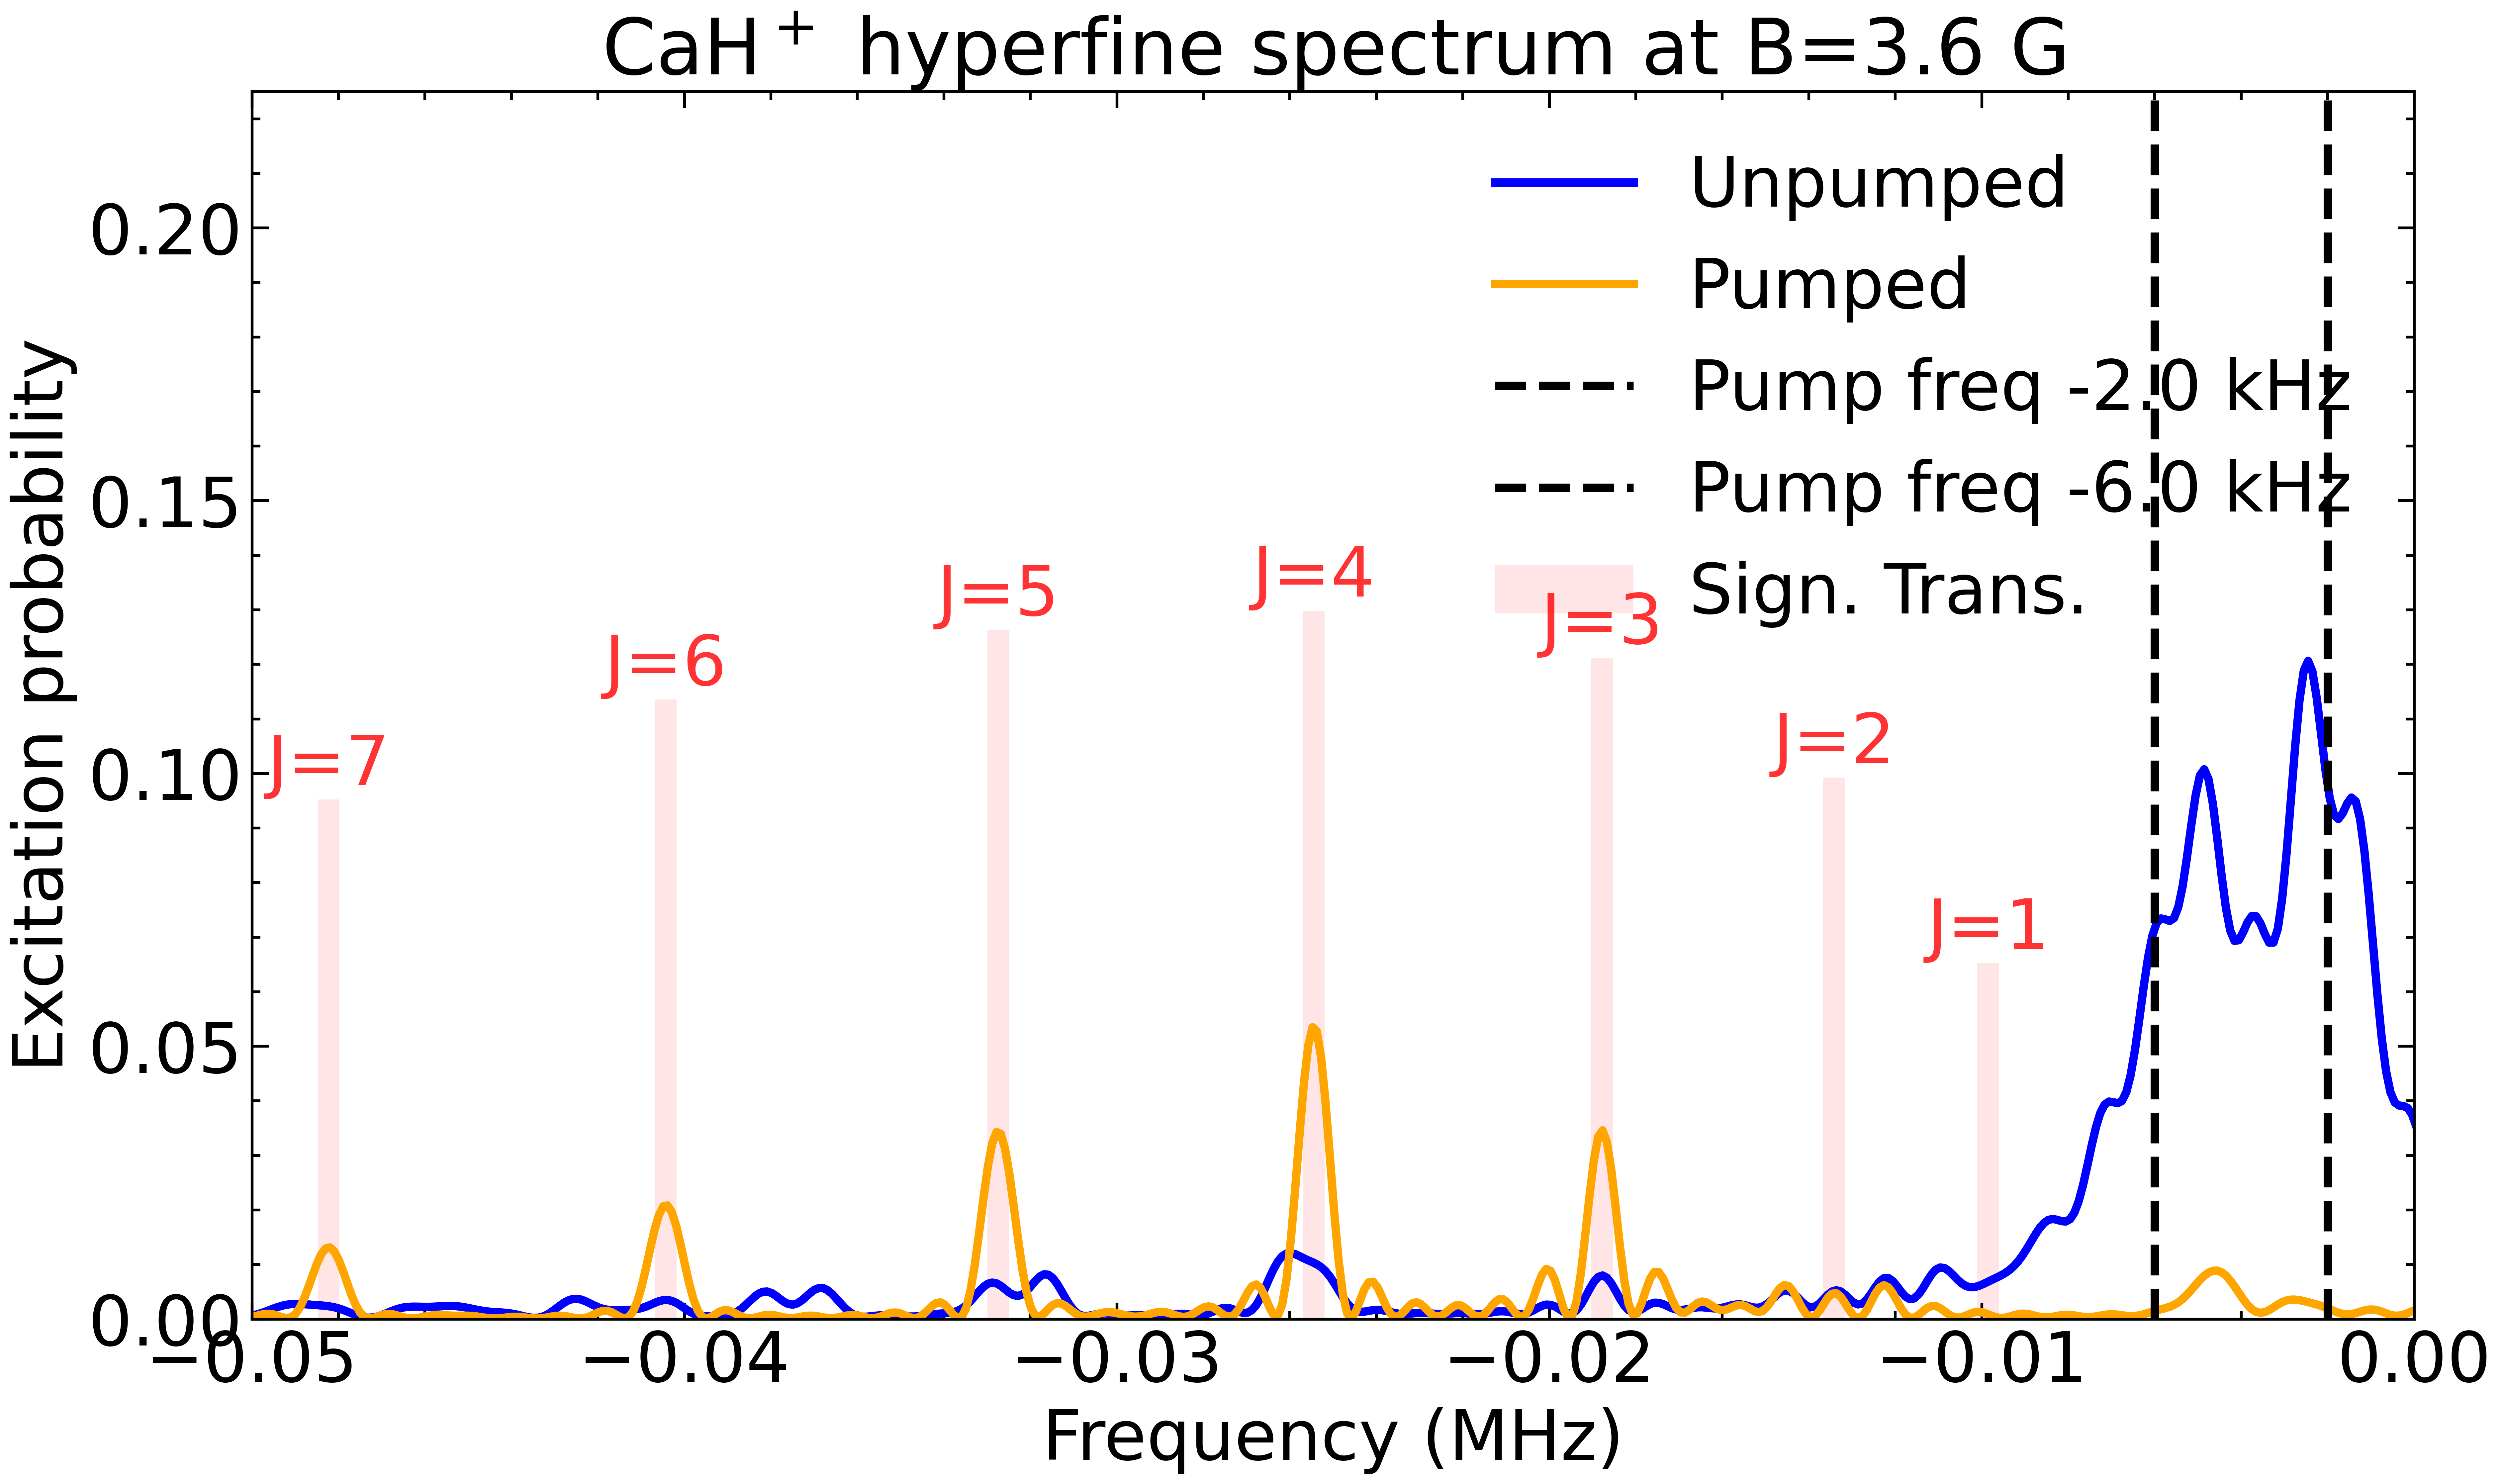

In [4]:
b_field_gauss = 3.6
j_max = 14

# I compute the molecule 
cah1 = CaH.create_molecule_data(b_field_gauss=b_field_gauss, j_max=j_max, gj_list = gj_list, cij_list = cij_list)

temperature = 300
states = state_dist.States(cah1, temperature)



# Then I apply the external Raman pulse. 
spectrum_list = {
    "duration_us": 1000.0,
    "rabi_rate_mhz": 2*np.pi*0.005,
    "max_frequency_mhz": 0.05,        # 50 kHz
    "scan_points": 1000,
    "dephased" : False,
    "coherence_time_us": 100,
    "is_minus" : True
}


# Then I pump the system n times to improve the population
pump_sequences = [
    {
        "frequency_mhz": -0.002,
        "num_pumps": 200,
        "duration_us": 1000.0,
        "rabi_rate_mhz": 2*np.pi*0.004,
        "dephased": True,
        "coherence_time_us": 100,
        "is_minus": True,
    },
    {
        "frequency_mhz": -0.006,
        "num_pumps": 200,
        "duration_us": 1000.0,
        "rabi_rate_mhz": 2*np.pi*0.004,
        "dephased": True,
        "coherence_time_us": 100,
        "is_minus": True,
    }
]



# laser_miscalibration = {
#     "frequency": {"type": "abs_gaussian", "level": 0.00005},
#     "rabi_rate": {"type": "rel_gaussian", "level": 0.1}
# }

# # If I want both lasers to have the SAME MISCALIBRATION
# seed_miscalibration = random.randint(0, 10000)

# # SHOT TO SHOT FLUCTUATIONS
# noise_params = {
#     "frequency": {"type": "abs_gaussian", "level": 0.00003},
#     "rabi_rate": {"type": "rel_gaussian", "level": 0.01}
# }

# false_positive_rate = 0.015


spectrum.unpumped_pumped(b_field_gauss, j_max, cah1, states, spectrum_list, pump_sequences, 
                filename = "unpumped.svg")

## Unpumped spectrum without ODF - with experimental imperfections

In this part we will compute the unpumped spectrum for CaH molecule without the ODF and with the experimental imperfections. The comparison with the case of having experimental imperfections is also reported. 

In particular we have:

- laser miscalibration on frequency gaussian distributed with sigma = 50 Hz and rabi rate gaussian distributed with a sigma to be the 10% of its nominal value. constant throughout the whole run
- shot-to-shot fluctuations on frequency gaussian distributed with sigma = 30 Hz and rabi rate gaussian distributed with a sigma to be the 1% of its nominal value. changes at each pulse
- false positive rate uniformly distributed to be 1.5%

Saved molecule data in:
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[14]_states.csv
/home/stripzio/bayesian-qls/re_project/molecule_data/CaH_B[3.60]_Jmax[14]_transitions.csv
Saved figure in: /home/stripzio/bayesian-qls/re_project/images/unpumped_w_wo_imperf.svg


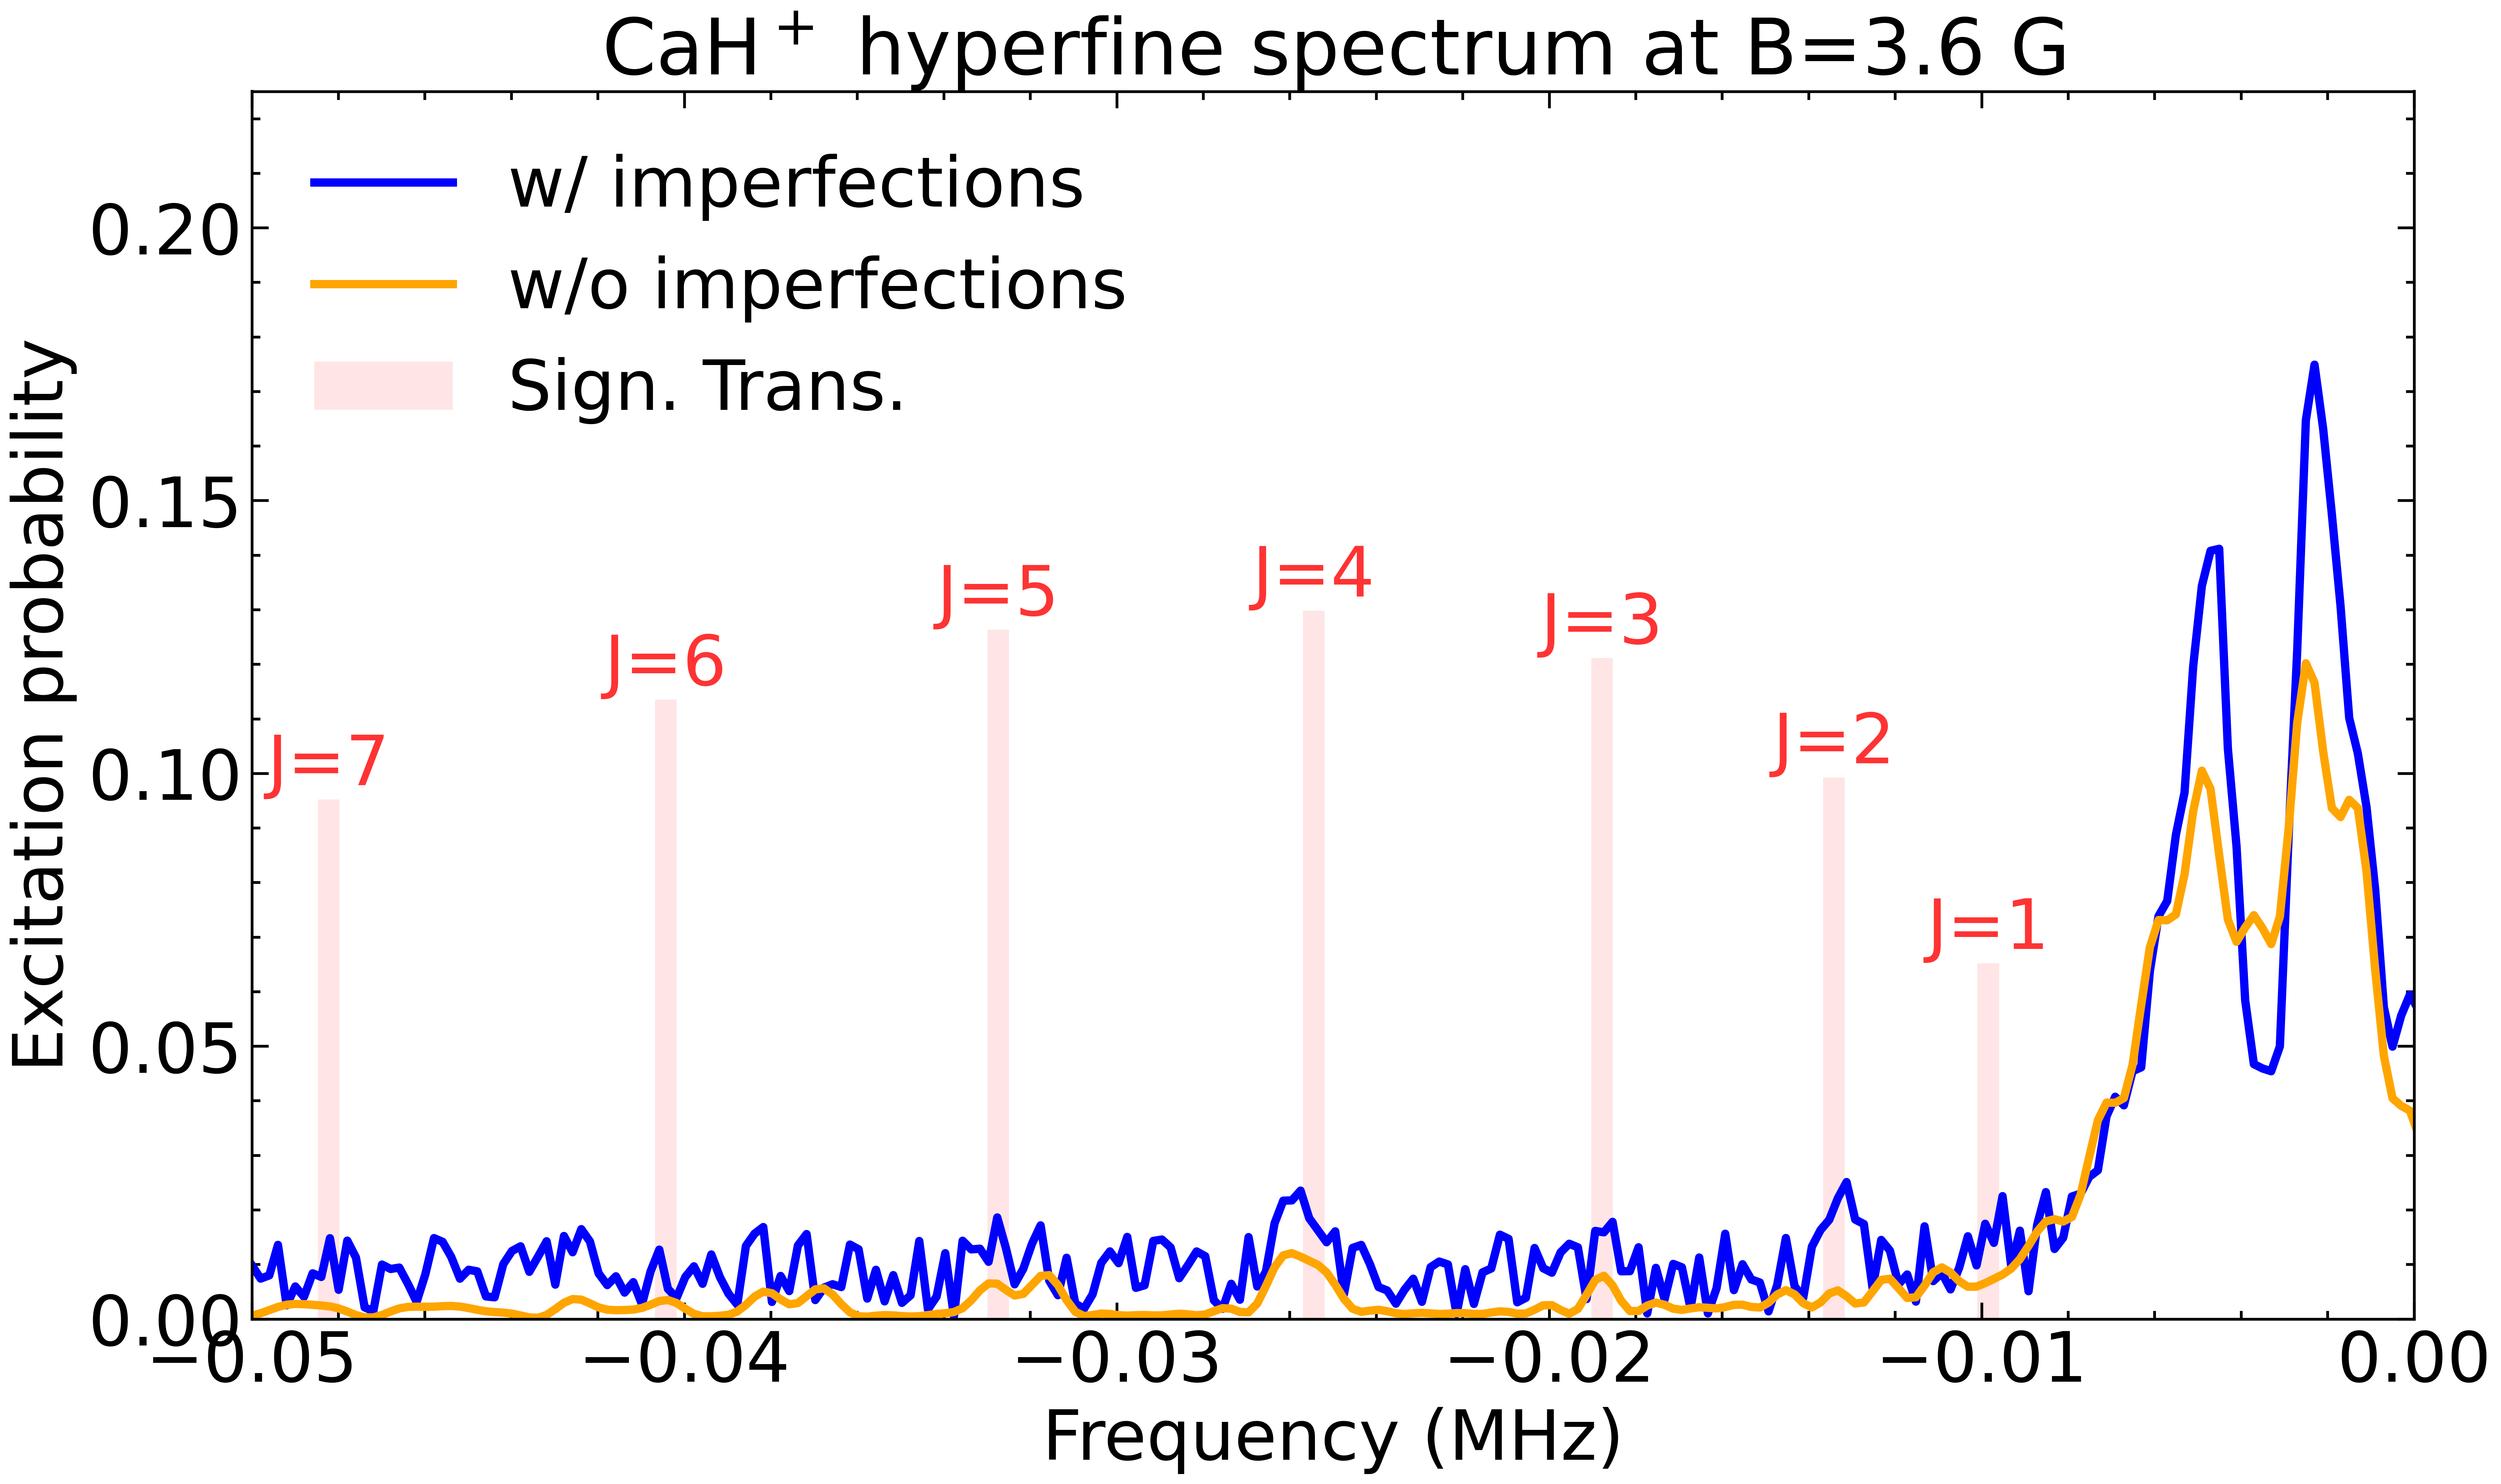

In [5]:
b_field_gauss = 3.6
j_max = 14

# I compute the molecule 
cah1 = CaH.create_molecule_data(b_field_gauss=b_field_gauss, j_max=j_max, gj_list = gj_list, cij_list = cij_list)

temperature = 300
states = state_dist.States(cah1, temperature)


# Then I apply the external Raman pulse. 
spectrum_list = {
    "duration_us": 1000.0,
    "rabi_rate_mhz": 2*np.pi*0.005,
    "max_frequency_mhz": 0.05,        # 50 kHz
    "scan_points": 500,
    "dephased" : False,
    "coherence_time_us": 100,
    "is_minus" : True
}


# Then I pump the system n times to improve the population
# pump_sequences = [
#     {
#         "frequency_mhz": -0.002,
#         "num_pumps": 200,
#         "duration_us": 1000.0,
#         "rabi_rate_mhz": 2*np.pi*0.004,
#         "dephased": True,
#         "coherence_time_us": 100,
#         "is_minus": True,
#     },
#     {
#         "frequency_mhz": -0.006,
#         "num_pumps": 200,
#         "duration_us": 1000.0,
#         "rabi_rate_mhz": 2*np.pi*0.004,
#         "dephased": True,
#         "coherence_time_us": 100,
#         "is_minus": True,
#     }
# ]



laser_miscalibration = {
    "frequency": {"type": "abs_gaussian", "level": 0.00005},
    "rabi_rate": {"type": "rel_gaussian", "level": 0.1}
}

# If I want both lasers to have the SAME MISCALIBRATION
seed_miscalibration = random.randint(0, 10000)

# SHOT TO SHOT FLUCTUATIONS
noise_params = {
    "frequency": {"type": "abs_gaussian", "level": 0.00003},
    "rabi_rate": {"type": "rel_gaussian", "level": 0.01}
}

false_positive_rate = 0.015


spectrum.spectrum_w_wo_imperfections(b_field_gauss, j_max, cah1, states, spectrum_list, pump_sequences=None,
                            noise_params=noise_params, laser_miscalibration=laser_miscalibration, 
                            seed_miscalibration=seed_miscalibration, false_positive_rate=false_positive_rate,
                            filename = "unpumped_w_wo_imperf.svg")